**Farah Khairunnisa Prakasa**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')
# Data Analysis
import numpy as np
import pandas as pd
# Data Visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import colors as mcolors
import plotly.graph_objects as go
import plotly.io as pio
# Data Pre-Processing & Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Modeling
from scipy.stats import linregress
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans

# Model Evaluation
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from yellowbrick.cluster import (
    KElbowVisualizer,
    SilhouetteVisualizer
)
# Other Utilities
from tabulate import tabulate
from collections import Counter
%matplotlib inline

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Bootcamp Data Science/ecommerce_data (1).csv', encoding = "iso-8859-1")

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


# OVERVIEW DATA

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.describe(include='object')

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/2011 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


# CLEANING DATA

In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df[df['CustomerID'].isnull()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,12/1/2010 11:52,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,12/1/2010 14:32,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,12/1/2010 14:32,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,12/1/2010 14:32,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,12/1/2010 14:32,1.66,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
541536,581498,85099B,JUMBO BAG RED RETROSPOT,5,12/9/2011 10:26,4.13,NaN,United Kingdom
541537,581498,85099C,JUMBO BAG BAROQUE BLACK WHITE,4,12/9/2011 10:26,4.13,NaN,United Kingdom
541538,581498,85150,LADIES & GENTLEMEN METAL SIGN,1,12/9/2011 10:26,4.96,NaN,United Kingdom
541539,581498,85174,S/4 CACTI CANDLES,1,12/9/2011 10:26,10.79,NaN,United Kingdom


In [ ]:
df.dropna(subset=['CustomerID'], inplace=True)

In [ ]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


## STANDARISASI DESKRIPSI

dibuat satu StockCode itu memiliki Description yang sama

In [ ]:
df[df['StockCode'] == '85123A']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 9:02,2.55,17850.0,United Kingdom
66,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 9:32,2.55,17850.0,United Kingdom
220,536390,85123A,WHITE HANGING HEART T-LIGHT HOLDER,64,12/1/2010 10:19,2.55,17511.0,United Kingdom
262,536394,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,12/1/2010 10:39,2.55,13408.0,United Kingdom
...,...,...,...,...,...,...,...,...
538708,581412,85123A,CREAM HANGING HEART T-LIGHT HOLDER,4,12/8/2011 14:38,2.95,14415.0,United Kingdom
539083,581432,85123A,CREAM HANGING HEART T-LIGHT HOLDER,32,12/8/2011 15:51,2.55,13798.0,United Kingdom
539979,581452,85123A,WHITE HANGING HEART T-LIGHT HOLDER,32,12/8/2011 18:03,2.55,17675.0,United Kingdom
540217,581472,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/8/2011 19:55,2.95,15796.0,United Kingdom


In [ ]:
master_product = df[['StockCode','Description']]
master_product.drop_duplicates(subset=['StockCode'], inplace=True)  # nyimpen description pertama

In [ ]:
df.drop('Description',axis=1,inplace=True)

In [ ]:
df_clean = df.merge(master_product, how = 'left', on = 'StockCode')

In [ ]:
master_product

,StockCode,Description
0,85123A,WHITE HANGING HEART T-LIGHT HOLDER
1,71053,WHITE METAL LANTERN
2,84406B,CREAM CUPID HEARTS COAT HANGER
3,84029G,KNITTED UNION FLAG HOT WATER BOTTLE
4,84029E,RED WOOLLY HOTTIE WHITE HEART.
...,...,...
527065,90214U,"LETTER ""U"" BLING KEY RING"
527067,90214W,"LETTER ""W"" BLING KEY RING"
527069,90214Z,"LETTER ""Z"" BLING KEY RING"
530382,90089,PINK CRYSTAL SKULL PHONE CHARM


In [ ]:
df

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France


## DUPLIKASI

In [ ]:
df_clean.duplicated().sum()

np.int64(5227)

In [ ]:
duplicate_rows = df_clean[df_clean.duplicated(keep=False)]
duplicate_rows = duplicate_rows.sort_values(
    by = ['InvoiceNo','StockCode', 'Quantity']
)
duplicate_rows

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description
494,536409,21866,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,UNION JACK FLAG LUGGAGE TAG
517,536409,21866,1,12/1/2010 11:45,1.25,17908.0,United Kingdom,UNION JACK FLAG LUGGAGE TAG
485,536409,22111,1,12/1/2010 11:45,4.95,17908.0,United Kingdom,SCOTTIE DOG HOT WATER BOTTLE
539,536409,22111,1,12/1/2010 11:45,4.95,17908.0,United Kingdom,SCOTTIE DOG HOT WATER BOTTLE
489,536409,22866,1,12/1/2010 11:45,2.10,17908.0,United Kingdom,HAND WARMER SCOTTY DOG DESIGN
...,...,...,...,...,...,...,...,...
330682,C574510,22360,-1,11/4/2011 13:25,2.95,15110.0,United Kingdom,GLASS JAR ENGLISH CONFECTIONERY
347324,C575940,23309,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom,SET OF 60 I LOVE LONDON CAKE CASES
347325,C575940,23309,-24,11/13/2011 11:38,0.55,17838.0,United Kingdom,SET OF 60 I LOVE LONDON CAKE CASES
399123,C580764,22667,-12,12/6/2011 10:38,2.95,14562.0,United Kingdom,RECIPE BOX RETROSPOT


In [ ]:
df_clean.drop_duplicates(inplace=True)

In [ ]:
df_clean.duplicated().sum()

np.int64(0)

In [ ]:
df_clean.shape

(401602, 8)

## KOLOM TAMBAHAN = FEATURE ENGINEER/PENANDA

In [ ]:
df_clean.head()

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,WHITE METAL LANTERN
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.


### InvoiceNo yang di depannya C artinya transaksi yang di cancel

In [ ]:
df_clean[df_clean['InvoiceNo'].astype(str).str.startswith('C')]

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description
141,C536379,D,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom,Discount
154,C536383,35004C,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom,SET OF 3 COLOURED FLYING DUCKS
235,C536391,22556,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom,PLASTERS IN TIN CIRCUS PARADE
236,C536391,21984,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,PACK OF 12 PINK PAISLEY TISSUES
237,C536391,21983,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom,PACK OF 12 BLUE PAISLEY TISSUES
...,...,...,...,...,...,...,...,...
406377,C581490,23144,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom,ZINC T-LIGHT HOLDER STARS SMALL
406461,C581499,M,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom,Manual
406635,C581568,21258,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom,VICTORIAN SEWING BOX LARGE
406636,C581569,84978,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom,HANGING HEART JAR T-LIGHT HOLDER


In [ ]:
df_clean['Transaction_Status'] = np.where(
        (
            df_clean['InvoiceNo']
            .astype(str)
            .str.startswith('C')
        ),
        'Cancelled',
        'Completed'
)

In [ ]:
cancelled_transactions = df_clean[df_clean['Transaction_Status'] == 'Cancelled']
(
    cancelled_transactions
    .describe()
    .drop('CustomerID', axis=1)
)

,Quantity,UnitPrice
count,8872.000000,8872.000000
mean,-30.774910,18.899512
std,1172.249902,445.190864
min,-80995.000000,0.010000
25%,-6.000000,1.450000
50%,-2.000000,2.950000
75%,-1.000000,4.950000
max,-1.000000,38970.000000


In [ ]:
df_clean2= df_clean[df_clean['Transaction_Status'] =='Completed' ]

In [ ]:
df_clean2.describe()

,Quantity,UnitPrice,CustomerID
count,392730.000000,392730.000000,392730.000000
mean,13.153014,3.125594,15287.746880
std,181.588304,22.240782,1713.563805
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13955.000000
50%,6.000000,1.950000,15150.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,8142.750000,18287.000000


## STOCKCODE Digit Anomali

In [ ]:
unique_stock_codes = df_clean2['StockCode'].unique()
numeric_char_counts_in_unique_codes = (
    pd.Series(unique_stock_codes)
    .apply(lambda x: sum(c.isdigit() for c in str(x)))
    .value_counts()
)

In [ ]:
numeric_char_counts_in_unique_codes

,count
5,3659
0,5
1,1


In [ ]:
anomalous_stock_codes = [code for code in unique_stock_codes if sum(c.isdigit() for c in str(code)) in (0, 1)]

for code in anomalous_stock_codes:
    print(code)

POST
C2
M
BANK CHARGES
PADS
DOT


In [ ]:
df_clean3 = df_clean2[~df_clean2['StockCode'].isin(anomalous_stock_codes)]

In [ ]:
df_clean3

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description,Transaction_Status
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,Completed
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,Completed
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,Completed
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,Completed
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,Completed
...,...,...,...,...,...,...,...,...,...
406824,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France,PACK OF 20 SPACEBOY NAPKINS,Completed
406825,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France,CHILDREN'S APRON DOLLY GIRL,Completed
406826,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France,CHILDRENS CUTLERY DOLLY GIRL,Completed
406827,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France,CHILDRENS CUTLERY CIRCUS PARADE,Completed


# PEMBERSIHAN DATA DESCRIPTION

In [ ]:
df_clean['Description'].value_counts().head(30)

,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2065
REGENCY CAKESTAND 3 TIER,1894
JUMBO BAG RED RETROSPOT,1659
PARTY BUNTING,1409
ASSORTED COLOUR BIRD ORNAMENT,1405
LUNCH BAG RED RETROSPOT,1346
SET OF 3 CAKE TINS PANTRY DESIGN,1224
POSTAGE,1196
SMALL POPCORN HOLDER,1110


In [ ]:
lowercase_descriptions = df_clean3['Description'].unique()
lowercase_descriptions = [desc for desc in lowercase_descriptions if any(char.islower() for char in desc)]
for desc in lowercase_descriptions:
    print(desc)

BAG 500g SWIRLY MARBLES
POLYESTER FILLER PAD 45x45cm
POLYESTER FILLER PAD 45x30cm
POLYESTER FILLER PAD 40x40cm
FRENCH BLUE METAL DOOR SIGN No
BAG 250g SWIRLY MARBLES
BAG 125g SWIRLY MARBLES
FOLK ART GREETING CARD,pack/12
ESSENTIAL BALM 3.5g TIN IN ENVELOPE
POLYESTER FILLER PAD 65CMx65CM
NUMBER TILE VINTAGE FONT No 
NUMBER TILE COTTAGE GARDEN No
POLYESTER FILLER PAD 30CMx30CM
POLYESTER FILLER PAD 60x40cm
FLOWERS HANDBAG blue and orange
Next Day Carriage
THE KING GIFT BAG 25x24x12cm
High Resolution Image


In [ ]:
df_clean3[df_clean3['Description']=='Next Day Carriage']

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description,Transaction_Status
146426,554835,23444,1,5/26/2011 16:11,15.0,15241.0,United Kingdom,Next Day Carriage,Completed
149608,555251,23444,1,6/1/2011 15:12,15.0,13062.0,United Kingdom,Next Day Carriage,Completed
149998,555312,23444,1,6/2/2011 10:39,15.0,16484.0,United Kingdom,Next Day Carriage,Completed
150346,555367,23444,1,6/2/2011 14:28,15.0,17900.0,United Kingdom,Next Day Carriage,Completed
156023,555948,23444,1,6/8/2011 10:49,30.0,13752.0,United Kingdom,Next Day Carriage,Completed
...,...,...,...,...,...,...,...,...,...
396046,580622,23444,1,12/5/2011 12:09,15.0,17006.0,United Kingdom,Next Day Carriage,Completed
396059,580630,23444,1,12/5/2011 12:11,15.0,12913.0,United Kingdom,Next Day Carriage,Completed
402385,581132,23444,1,12/7/2011 12:55,15.0,17590.0,United Kingdom,Next Day Carriage,Completed
403707,581221,23444,1,12/8/2011 9:40,15.0,17856.0,United Kingdom,Next Day Carriage,Completed


In [ ]:
df_clean3[df_clean3['Description']=='High Resolution Image']

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description,Transaction_Status
302189,571739,23702,1,10/19/2011 10:33,3.0,12500.0,Germany,High Resolution Image,Completed
346829,575910,23702,2,11/11/2011 16:05,1.5,14836.0,United Kingdom,High Resolution Image,Completed
355513,576659,23702,1,11/16/2011 11:09,21.0,15373.0,United Kingdom,High Resolution Image,Completed


### Hapus deskripsi product yang tidak menggambarkan product (deskripsinya aneh)

In [ ]:
buang_deskripsi = ['Next Day Carriage','High Resolution Image']

In [ ]:
df_clean4 = df_clean3[~df_clean3['StockCode'].isin(buang_deskripsi)]

In [ ]:
df_clean4

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description,Transaction_Status
0,536365,85123A,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,Completed
1,536365,71053,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,Completed
2,536365,84406B,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,Completed
3,536365,84029G,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,Completed
4,536365,84029E,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,Completed
...,...,...,...,...,...,...,...,...,...
406824,581587,22613,12,12/9/2011 12:50,0.85,12680.0,France,PACK OF 20 SPACEBOY NAPKINS,Completed
406825,581587,22899,6,12/9/2011 12:50,2.10,12680.0,France,CHILDREN'S APRON DOLLY GIRL,Completed
406826,581587,23254,4,12/9/2011 12:50,4.15,12680.0,France,CHILDRENS CUTLERY DOLLY GIRL,Completed
406827,581587,23255,4,12/9/2011 12:50,4.15,12680.0,France,CHILDRENS CUTLERY CIRCUS PARADE,Completed


In [ ]:
df_clean4['Description'] = df_clean4['Description'].str.upper()

# CLUSTERING RFM

## RECENCY = KETERBARUAN PEMBELIAN

In [ ]:
df_clean4.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country', 'Description', 'Transaction_Status'],
      dtype='object')

In [ ]:
df_clean4['InvoiceDate'] = pd.to_datetime(df_clean4['InvoiceDate'])

In [ ]:
df_clean4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391181 entries, 0 to 406828
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   InvoiceNo           391181 non-null  object        
 1   StockCode           391181 non-null  object        
 2   Quantity            391181 non-null  int64         
 3   InvoiceDate         391181 non-null  datetime64[ns]
 4   UnitPrice           391181 non-null  float64       
 5   CustomerID          391181 non-null  float64       
 6   Country             391181 non-null  object        
 7   Description         391181 non-null  object        
 8   Transaction_Status  391181 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 29.8+ MB


In [ ]:
df_clean4['InvoiceDay'] = df_clean4['InvoiceDate'].dt.date

In [ ]:
customer_data = (
    df_clean4
    .groupby('CustomerID')['InvoiceDay']
    .max()
    .reset_index()
)

In [ ]:
most_recent_date = df_clean4['InvoiceDay'].max()

In [ ]:
most_recent_date

datetime.date(2011, 12, 9)

In [ ]:
customer_data['InvoiceDay'] = pd.to_datetime(customer_data['InvoiceDay'])
most_recent_date = pd.to_datetime(most_recent_date)

In [ ]:
customer_data['Days_Since_Last_Purchase'] = (
    (most_recent_date - customer_data['InvoiceDay'])
    .dt
    .days
)

In [ ]:
customer_data.drop(
    columns=['InvoiceDay'],
    inplace=True
)

In [ ]:
customer_data

,CustomerID,Days_Since_Last_Purchase
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310
...,...,...
4330,18280.0,277
4331,18281.0,180
4332,18282.0,7
4333,18283.0,3


### Tugas 1: TOP 5 customer aktif beli dan TOP 5 paling jarang beli

In [ ]:
freq_transaction = df_clean4.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
freq_transaction.columns = ['CustomerID','Frequency']
freq_transaction

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4330,18280.0,1
4331,18281.0,1
4332,18282.0,2
4333,18283.0,16


In [ ]:
total_product_purchased = df_clean4.groupby('CustomerID')['Quantity'].sum().reset_index()
total_product_purchased.columns = ['CustomerID','TotalQty']
total_product_purchased

,CustomerID,TotalQty
0,12346.0,74215
1,12347.0,2458
2,12348.0,2332
3,12349.0,630
4,12350.0,196
...,...,...
4330,18280.0,45
4331,18281.0,54
4332,18282.0,103
4333,18283.0,1355


In [ ]:
customer_data = customer_data.merge(freq_transaction, how = 'left', on='CustomerID')
customer_data = customer_data.merge(total_product_purchased, how = 'left', on='CustomerID')
customer_data

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty
0,12346.0,325,1,74215
1,12347.0,2,7,2458
2,12348.0,75,4,2332
3,12349.0,18,1,630
4,12350.0,310,1,196
...,...,...,...,...
4330,18280.0,277,1,45
4331,18281.0,180,1,54
4332,18282.0,7,2,103
4333,18283.0,3,16,1355


In [ ]:
customer_data.sort_values(
    by='Days_Since_Last_Purchase',
    ascending=True
).head(5)

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty
71,12433.0,0,7,11071
489,12985.0,0,2,1533
137,12518.0,0,5,1306
3379,16954.0,0,9,1054
144,12526.0,0,3,624


Kelima customer tersebut melakukan pembelian pada tanggal transaksi paling terakhir dalam dataset. Dengan kata lain, mereka termasuk customer yang paling aktif secara recency, karena masih melakukan transaksi sampai periode terbaru yang tercatat.

In [ ]:
customer_data.sort_values(
    by='Days_Since_Last_Purchase',
    ascending=False
).head(5)

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty
1038,13747.0,373,1,8
4061,17908.0,373,1,169
2714,16048.0,373,2,144
2882,16274.0,373,1,151
4105,17968.0,373,1,151


Kelima customer tersebut terakhir melakukan pembelian 373 hari sebelum tanggal transaksi terbaru dalam dataset. Mereka dapat dikategorikan sebagai customer yang paling lama tidak melakukan pembelian atau paling tidak aktif secara recency.

### Tugas 2: Buatlah grafik yang menampilkan distribusi hari

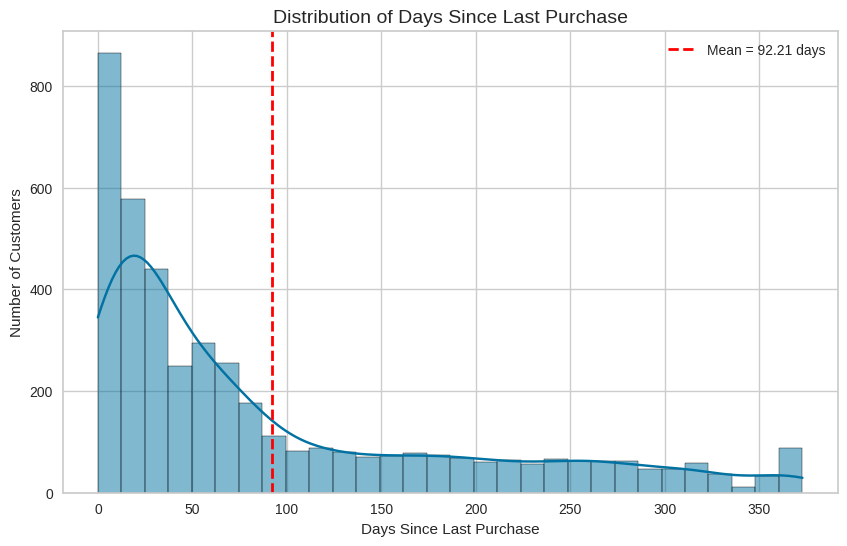

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil data hari sejak pembelian terakhir
days_data = customer_data['Days_Since_Last_Purchase'].dropna()

# Hitung nilai mean
mean_days = days_data.mean()

# Membuat histogram
plt.figure(figsize=(10, 6))

sns.histplot(
    days_data,
    bins=30,
    kde=True
)

# Garis penanda mean
plt.axvline(
    mean_days,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {mean_days:.2f} days'
)

# Judul dan label
plt.title('Distribution of Days Since Last Purchase', fontsize=14)
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Number of Customers')

# Tampilkan legend
plt.legend()

# Tampilkan grafik
plt.show()

- Sumbu X menunjukkan jumlah hari sejak customer terakhir melakukan pembelian.
- Sumbu Y menunjukkan jumlah customer.
- Bar yang tinggi di dekat angka kecil berarti banyak customer yang masih aktif atau baru saja membeli.
- Bar yang tinggi di angka besar berarti banyak customer sudah lama tidak membeli.
- Garis merah putus-putus menunjukkan rata-rata jumlah hari sejak pembelian terakhir.

- Sebagian besar customer memiliki nilai Days Since Last Purchase yang rendah, terutama di sekitar 0–50 hari. Ini menunjukkan banyak customer masih relatif aktif atau baru melakukan pembelian dalam waktu dekat.
- Jumlah customer semakin menurun ketika nilai hari semakin besar. Artinya, semakin lama jarak dari pembelian terakhir, semakin sedikit jumlah customer-nya.
- Terdapat sebagian customer yang sudah lama tidak membeli, bahkan mendekati 300–370 hari. Kelompok ini dapat dianggap sebagai customer yang mulai tidak aktif atau berisiko hilang.
- Nilai mean = 92,21 hari berada cukup jauh ke kanan dari puncak histogram. Ini terjadi karena ada beberapa customer dengan nilai hari yang sangat besar, sehingga rata-rata tertarik ke arah kanan.
- Karena distribusinya menceng kanan, rata-rata belum tentu mewakili mayoritas customer. Mayoritas customer kemungkinan memiliki nilai hari yang lebih kecil dari mean.

Kesimpulannya, mayoritas customer masih melakukan pembelian dalam periode yang relatif dekat, tetapi terdapat sebagian customer yang sudah sangat lama tidak membeli. Dalam RFM, pola ini menunjukkan adanya kelompok customer aktif dan kelompok customer yang perlu strategi reaktivasi.

##FREQUENCY

In [ ]:
print("Top 5 most active customers (by frequency):")
print(freq_transaction.sort_values(by='Frequency', ascending=False).head(5))

print("\nTop 5 least active customers (by frequency):")
print(freq_transaction.sort_values(by='Frequency', ascending=True).head(5))

Top 5 most active customers (by frequency):
      CustomerID  Frequency
326      12748.0        206
1880     14911.0        198
4008     17841.0        124
562      13089.0         97
2177     15311.0         91

Top 5 least active customers (by frequency):
      CustomerID  Frequency
4326     18274.0          1
4322     18269.0          1
4321     18268.0          1
4318     18262.0          1
4313     18255.0          1


In [ ]:
freq_transaction = df_clean4.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
freq_transaction.columns = ['CustomerID','Frequency']
freq_transaction

,CustomerID,Frequency
0,12346.0,1
1,12347.0,7
2,12348.0,4
3,12349.0,1
4,12350.0,1
...,...,...
4330,18280.0,1
4331,18281.0,1
4332,18282.0,2
4333,18283.0,16


In [ ]:
total_product_purchased = df_clean4.groupby('CustomerID')['Quantity'].sum().reset_index()
total_product_purchased.columns = ['CustomerID','TotalQty']
total_product_purchased

,CustomerID,TotalQty
0,12346.0,74215
1,12347.0,2458
2,12348.0,2332
3,12349.0,630
4,12350.0,196
...,...,...
4330,18280.0,45
4331,18281.0,54
4332,18282.0,103
4333,18283.0,1355


### Tugas 3: Secara rata-rata customer beli dalam berapa transaksi dan berapa quantity?

Apakah ini bisa dijadikan ambang batas customer loyal atau tidaknya?

In [ ]:
# Membuat data frequency dan total quantity per customer
customer_frequency = (
    df_clean4
    .groupby('CustomerID')
    .agg(
        Frequency=('InvoiceNo', 'nunique'),
        TotalQty=('Quantity', 'sum')
    )
    .reset_index()
)

customer_frequency.head()

,CustomerID,Frequency,TotalQty
0,12346.0,1,74215
1,12347.0,7,2458
2,12348.0,4,2332
3,12349.0,1,630
4,12350.0,1,196


In [ ]:
# Ringkasan rata-rata pembelian customer
avg_customer_purchase = pd.DataFrame({
    'Average Frequency per Customer': [customer_frequency['Frequency'].mean()],
    'Average Quantity per Customer': [customer_frequency['TotalQty'].mean()]
})

avg_customer_purchase

,Average Frequency per Customer,Average Quantity per Customer
0,4.245675,1189.2406


- Average Frequency per Customer = rata-rata jumlah transaksi yang dilakukan oleh setiap customer.
- Average Quantity per Customer = rata-rata total quantity produk yang dibeli oleh setiap customer.

- Rata-rata Frequency per Customer = 4,25 transaksi.
- Artinya, secara umum satu customer melakukan sekitar 4 transaksi selama periode data.
- Rata-rata Quantity per Customer = 1.189 unit.
- Artinya, secara umum satu customer membeli sekitar 1.189 unit produk selama periode data.

Customer dengan jumlah transaksi di atas 4 kali dapat dianggap lebih aktif dibandingkan rata-rata customer lainnya. Sebaliknya, customer dengan transaksi di bawah 4 kali cenderung kurang aktif dibandingkan rata-rata.

Menurut saya, nilai rata-rata ini boleh digunakan sebagai benchmark awal, tetapi kurang tepat jika langsung dijadikan ambang batas final loyal atau tidak loyal.

Rata-rata belum cukup kuat sebagai ambang loyalitas.
- Pertama, data customer biasanya tidak merata. Ada customer yang belinya sangat besar atau sangat sering, sehingga nilai rata-rata bisa tertarik naik. Contohnya pada tabel, customer 12346 hanya memiliki Frequency = 1, tetapi TotalQty = 74215. Ini berarti customer tersebut membeli quantity sangat besar dalam satu transaksi, tetapi belum tentu loyal, karena hanya transaksi satu kali.
- Kedua, loyalitas lebih cocok dilihat dari Frequency dan Recency, bukan hanya Quantity. Customer yang membeli 10 kali dengan quantity kecil bisa lebih loyal daripada customer yang membeli 1 kali dengan quantity sangat besar.
- Ketiga, rata-rata quantity sebesar 1.189 unit bisa menjadi kurang representatif jika ada outlier. Jika ada beberapa customer dengan pembelian quantity ekstrem, maka rata-rata quantity akan terlihat tinggi, padahal mayoritas customer mungkin membeli jauh di bawah angka tersebut.


**Ambang batas yang lebih disarankan**

Untuk menentukan customer loyal, lebih baik gunakan kombinasi:
1. Recency rendah → baru saja membeli.
2. Frequency tinggi → sering membeli.
3. Monetary tinggi → total belanja besar.

## MONETARY

In [ ]:
df_clean4.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country', 'Description', 'Transaction_Status',
       'InvoiceDay'],
      dtype='object')

In [ ]:
df_clean4['TotalSpent'] = df_clean4['Quantity'] * df_clean4['UnitPrice']

In [ ]:
df_clean4['TotalSpent'] = df_clean4['Quantity'] * df_clean4['UnitPrice']

total_spending = df_clean4.groupby('CustomerID')['TotalSpent'].sum().reset_index()
total_spending

,CustomerID,TotalSpent
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1437.24
3,12349.0,1457.55
4,12350.0,294.40
...,...,...
4330,18280.0,180.60
4331,18281.0,80.82
4332,18282.0,178.05
4333,18283.0,2039.58


In [ ]:
customer_data = customer_data.merge(total_spending, how = 'left', on='CustomerID')

In [ ]:
customer_data

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty,TotalSpent
0,12346.0,325,1,74215,77183.60
1,12347.0,2,7,2458,4310.00
2,12348.0,75,4,2332,1437.24
3,12349.0,18,1,630,1457.55
4,12350.0,310,1,196,294.40
...,...,...,...,...,...
4330,18280.0,277,1,45,180.60
4331,18281.0,180,1,54,80.82
4332,18282.0,7,2,103,178.05
4333,18283.0,3,16,1355,2039.58


### TUGAS 4: FEATURE ENGINEERING

- DIVERSITY = per customer, berapa jumlah unique product yang dibeli
- SPENDING = per customer, rata-rata monthly spending
-


In [ ]:
# Copy data
df_fe = df_clean4.copy()

# Pastikan InvoiceDate sudah datetime
df_fe['InvoiceDate'] = pd.to_datetime(df_fe['InvoiceDate'])

# Membuat kolom bulan transaksi
df_fe['InvoiceMonth'] = df_fe['InvoiceDate'].dt.to_period('M')

#### Diversity: jumlah unique product per customer

In [ ]:
diversity_feature = (
    df_fe
    .groupby('CustomerID')['StockCode']
    .nunique()
    .reset_index()
)

diversity_feature.columns = ['CustomerID', 'Diversity']

diversity_feature.head()

,CustomerID,Diversity
0,12346.0,1
1,12347.0,103
2,12348.0,21
3,12349.0,72
4,12350.0,16


In [ ]:
diversity_feature.sort_values(by='Diversity', ascending=False).head(5)

,CustomerID,Diversity
1880,14911.0,1785
326,12748.0,1766
4008,17841.0,1322
1290,14096.0,1118
1435,14298.0,884


In [ ]:
diversity_feature.sort_values(by='Diversity', ascending=True).head(5)

,CustomerID,Diversity
0,12346.0,1
576,13106.0,1
3951,17752.0,1
3948,17747.0,1
2506,15753.0,1


Semakin tinggi Diversity, semakin banyak jenis produk berbeda yang pernah dibeli oleh customer.

#### Average Monthly Spending

In [ ]:
# Total spending per customer per bulan
monthly_spending = (
    df_fe
    .groupby(['CustomerID', 'InvoiceMonth'])['TotalSpent']
    .sum()
    .reset_index()
)

monthly_spending.columns = ['CustomerID', 'InvoiceMonth', 'MonthlySpent']

# Rata-rata spending per bulan aktif
avg_monthly_spending = (
    monthly_spending
    .groupby('CustomerID')['MonthlySpent']
    .mean()
    .reset_index()
)

avg_monthly_spending.columns = ['CustomerID', 'AvgMonthlySpending']

avg_monthly_spending.head()

,CustomerID,AvgMonthlySpending
0,12346.0,77183.600000
1,12347.0,615.714286
2,12348.0,359.310000
3,12349.0,1457.550000
4,12350.0,294.400000


In [ ]:
avg_monthly_spending.sort_values(by='AvgMonthlySpending', ascending=False).head(5)

,CustomerID,AvgMonthlySpending
3007,16446.0,84236.250000
0,12346.0,77183.600000
2012,15098.0,39916.500000
2503,15749.0,22267.150000
4198,18102.0,21638.108333


In [ ]:
avg_monthly_spending.sort_values(by='AvgMonthlySpending', ascending=True).head(5)

,CustomerID,AvgMonthlySpending
685,13256.0,0.00
3216,16738.0,3.75
3013,16454.0,5.90
1794,14792.0,6.20
3993,17816.0,9.14


AvgMonthlySpending menunjukkan rata-rata total belanja customer pada bulan-bulan ketika customer tersebut aktif melakukan transaksi.

Ini menghitung rata-rata hanya pada bulan aktif, bukan semua bulan dalam periode dataset. Jadi kalau customer hanya beli di 2 bulan, rata-ratanya dihitung dari 2 bulan tersebut.

#### Average Order Value

In [ ]:
# Total spending dan frequency per customer
order_value_feature = (
    df_fe
    .groupby('CustomerID')
    .agg(
        TotalSpent=('TotalSpent', 'sum'),
        Frequency=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

# Rata-rata nilai belanja per transaksi
order_value_feature['AvgOrderValue'] = (
    order_value_feature['TotalSpent'] / order_value_feature['Frequency']
)

order_value_feature = order_value_feature[
    ['CustomerID', 'AvgOrderValue']
]

order_value_feature.head()

,CustomerID,AvgOrderValue
0,12346.0,77183.600000
1,12347.0,615.714286
2,12348.0,359.310000
3,12349.0,1457.550000
4,12350.0,294.400000


In [ ]:
order_value_feature.sort_values(by='AvgOrderValue', ascending=False).head(5)

,CustomerID,AvgOrderValue
3007,16446.0,84236.250000
0,12346.0,77183.600000
2503,15749.0,14844.766667
2012,15098.0,13305.500000
196,12590.0,9341.260000


In [ ]:
order_value_feature.sort_values(by='AvgOrderValue', ascending=True).head(5)

,CustomerID,AvgOrderValue
685,13256.0,0.00
3216,16738.0,3.75
3013,16454.0,5.90
1794,14792.0,6.20
3993,17816.0,9.14


AvgOrderValue menunjukkan rata-rata nilai uang yang dikeluarkan customer dalam satu transaksi.

In [ ]:
basket_size_feature = (
    df_fe
    .groupby('CustomerID')
    .agg(
        TotalQty=('Quantity', 'sum'),
        Frequency=('InvoiceNo', 'nunique')
    )
    .reset_index()
)

basket_size_feature['AvgBasketSize'] = (
    basket_size_feature['TotalQty'] / basket_size_feature['Frequency']
)

basket_size_feature = basket_size_feature[
    ['CustomerID', 'AvgBasketSize']
]

basket_size_feature.head()

,CustomerID,AvgBasketSize
0,12346.0,74215.000000
1,12347.0,351.142857
2,12348.0,583.000000
3,12349.0,630.000000
4,12350.0,196.000000


In [ ]:
basket_size_feature.sort_values(by='AvgBasketSize', ascending=False).head(5)

,CustomerID,AvgBasketSize
0,12346.0,74215.000000
3007,16446.0,40498.500000
685,13256.0,12540.000000
4311,18251.0,7824.000000
2503,15749.0,6009.333333


In [ ]:
basket_size_feature.sort_values(by='AvgBasketSize', ascending=True).head(5)

,CustomerID,AvgBasketSize
825,13452.0,1.0
2872,16257.0,1.0
4095,17956.0,1.0
4321,18268.0,2.0
2322,15510.0,2.0


AvgBasketSize menunjukkan rata-rata jumlah item yang dibeli customer dalam satu transaksi.

#### Customer Lifetime Days

In [ ]:
lifetime_feature = (
    df_fe
    .groupby('CustomerID')
    .agg(
        FirstPurchase=('InvoiceDate', 'min'),
        LastPurchase=('InvoiceDate', 'max')
    )
    .reset_index()
)

lifetime_feature['CustomerLifetimeDays'] = (
    lifetime_feature['LastPurchase'] - lifetime_feature['FirstPurchase']
).dt.days

lifetime_feature = lifetime_feature[
    ['CustomerID', 'CustomerLifetimeDays']
]

lifetime_feature.head()

,CustomerID,CustomerLifetimeDays
0,12346.0,0
1,12347.0,365
2,12348.0,282
3,12349.0,0
4,12350.0,0


CustomerLifetimeDays menunjukkan rentang waktu hubungan customer dengan toko, dari transaksi pertama sampai transaksi terakhir.

### Customer Data after Feature Engineering

In [ ]:
customer_features = (
    customer_data
    .merge(diversity_feature, on='CustomerID', how='left')
    .merge(avg_monthly_spending, on='CustomerID', how='left')
    .merge(order_value_feature, on='CustomerID', how='left')
    .merge(basket_size_feature, on='CustomerID', how='left')
    .merge(lifetime_feature, on='CustomerID', how='left')
)

customer_features.head()

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty,TotalSpent,Diversity,AvgMonthlySpending,AvgOrderValue,AvgBasketSize,CustomerLifetimeDays
0,12346.0,325,1,74215,77183.60,1,77183.600000,77183.600000,74215.000000,0
1,12347.0,2,7,2458,4310.00,103,615.714286,615.714286,351.142857,365
2,12348.0,75,4,2332,1437.24,21,359.310000,359.310000,583.000000,282
3,12349.0,18,1,630,1457.55,72,1457.550000,1457.550000,630.000000,0
4,12350.0,310,1,196,294.40,16,294.400000,294.400000,196.000000,0


In [ ]:
selected_features = customer_features[
    [
        'CustomerID',
        'Days_Since_Last_Purchase',
        'Frequency',
        'TotalQty',
        'Diversity',
        'AvgMonthlySpending',
        'AvgOrderValue',
        'AvgBasketSize',
        'CustomerLifetimeDays'
    ]
]

selected_features.head()

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty,Diversity,AvgMonthlySpending,AvgOrderValue,AvgBasketSize,CustomerLifetimeDays
0,12346.0,325,1,74215,1,77183.600000,77183.600000,74215.000000,0
1,12347.0,2,7,2458,103,615.714286,615.714286,351.142857,365
2,12348.0,75,4,2332,21,359.310000,359.310000,583.000000,282
3,12349.0,18,1,630,72,1457.550000,1457.550000,630.000000,0
4,12350.0,310,1,196,16,294.400000,294.400000,196.000000,0


# CLUSTERING RFM

In [ ]:
customer_data

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty,TotalSpent
0,12346.0,325,1,74215,77183.60
1,12347.0,2,7,2458,4310.00
2,12348.0,75,4,2332,1437.24
3,12349.0,18,1,630,1457.55
4,12350.0,310,1,196,294.40
...,...,...,...,...,...
4330,18280.0,277,1,45,180.60
4331,18281.0,180,1,54,80.82
4332,18282.0,7,2,103,178.05
4333,18283.0,3,16,1355,2039.58


In [ ]:
customer_data['Avg_Qty_Per_Transaction'] = customer_data['TotalQty'] / customer_data['Frequency']

In [ ]:
customer_data['Category_Recency'] = np.where(
    customer_data['Days_Since_Last_Purchase'] < customer_data['Days_Since_Last_Purchase'].median(),
    'Tinggi',
    'Rendah'
)

In [ ]:
customer_data['Category_Frequency'] = np.where(
    customer_data['Avg_Qty_Per_Transaction'] > customer_data['Avg_Qty_Per_Transaction'].median(),
    'Tinggi',
    'Rendah'
)

In [ ]:
customer_data['Category_Monetary'] = np.where(
    customer_data['TotalSpent'] > customer_data['TotalSpent'].median(),
    'Tinggi',
    'Rendah'
)

* rata-rata recency rendah (baru aja beli), tinggi frequency, monetary tinggi  = "Gold"
* rata-rata recency tinggi, frequency rendah, monetary rendah
="Hibernating"
* rata-rata recency tinggi, frequecny tinggi, monetary tinggi
= "Targeted"

In [ ]:
conditions = [
    (customer_data['Category_Recency'] == 'Tinggi') & (customer_data['Category_Frequency'] == 'Tinggi') & (customer_data['Category_Monetary'] == 'Tinggi'),
    (customer_data['Category_Recency'] == 'Tinggi') & (customer_data['Category_Frequency'] == 'Rendah') & (customer_data['Category_Monetary'] == 'Rendah'),
    (customer_data['Category_Recency'] == 'Rendah') & (customer_data['Category_Frequency'] == 'Tinggi') & (customer_data['Category_Monetary'] == 'Tinggi')
]

choices = ['Targeted', 'Hibernating', 'Gold']

customer_data['Cluster'] = np.select(conditions, choices, default='Other')

In [ ]:
customer_data

,CustomerID,Days_Since_Last_Purchase,Frequency,TotalQty,TotalSpent,Avg_Qty_Per_Transaction,Category_Recency,Category_Frequency,Category_Monetary,Cluster
0,12346.0,325,1,74215,77183.60,74215.000000,Rendah,Tinggi,Tinggi,Gold
1,12347.0,2,7,2458,4310.00,351.142857,Tinggi,Tinggi,Tinggi,Targeted
2,12348.0,75,4,2332,1437.24,583.000000,Rendah,Tinggi,Tinggi,Gold
3,12349.0,18,1,630,1457.55,630.000000,Tinggi,Tinggi,Tinggi,Targeted
4,12350.0,310,1,196,294.40,196.000000,Rendah,Tinggi,Rendah,Other
...,...,...,...,...,...,...,...,...,...,...
4330,18280.0,277,1,45,180.60,45.000000,Rendah,Rendah,Rendah,Other
4331,18281.0,180,1,54,80.82,54.000000,Rendah,Rendah,Rendah,Other
4332,18282.0,7,2,103,178.05,51.500000,Tinggi,Rendah,Rendah,Hibernating
4333,18283.0,3,16,1355,2039.58,84.687500,Tinggi,Rendah,Tinggi,Other


In [ ]:
df_clean_cluster = df_clean4.merge(customer_data[['CustomerID','Cluster']], how = 'left', on='CustomerID')

In [ ]:
df_clean_cluster

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Description,Transaction_Status,InvoiceDay,TotalSpent,Cluster
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,WHITE HANGING HEART T-LIGHT HOLDER,Completed,2010-12-01,15.30,Other
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,WHITE METAL LANTERN,Completed,2010-12-01,20.34,Other
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,CREAM CUPID HEARTS COAT HANGER,Completed,2010-12-01,22.00,Other
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,KNITTED UNION FLAG HOT WATER BOTTLE,Completed,2010-12-01,20.34,Other
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,RED WOOLLY HOTTIE WHITE HEART.,Completed,2010-12-01,20.34,Other
...,...,...,...,...,...,...,...,...,...,...,...,...
391176,581587,22613,12,2011-12-09 12:50:00,0.85,12680.0,France,PACK OF 20 SPACEBOY NAPKINS,Completed,2011-12-09,10.20,Other
391177,581587,22899,6,2011-12-09 12:50:00,2.10,12680.0,France,CHILDREN'S APRON DOLLY GIRL,Completed,2011-12-09,12.60,Other
391178,581587,23254,4,2011-12-09 12:50:00,4.15,12680.0,France,CHILDRENS CUTLERY DOLLY GIRL,Completed,2011-12-09,16.60,Other
391179,581587,23255,4,2011-12-09 12:50:00,4.15,12680.0,France,CHILDRENS CUTLERY CIRCUS PARADE,Completed,2011-12-09,16.60,Other


In [ ]:
df_clean_cluster.columns

Index(['InvoiceNo', 'StockCode', 'Quantity', 'InvoiceDate', 'UnitPrice',
       'CustomerID', 'Country', 'Description', 'Transaction_Status',
       'InvoiceDay', 'TotalSpent', 'Cluster'],
      dtype='object')

# TUGAS 5: KARAKTERISTIK CUSTOMER PER CLUSTER

## Jumlah customer per cluster

In [ ]:
# Jumlah customer per cluster
customer_count_per_cluster = (
    df_clean_cluster
    .groupby('Cluster')['CustomerID']
    .nunique()
    .reset_index()
)

customer_count_per_cluster.columns = ['Cluster', 'Customer_Count']

customer_count_per_cluster = customer_count_per_cluster.sort_values(
    by='Customer_Count',
    ascending=False
)

customer_count_per_cluster['Percentage'] = (
    customer_count_per_cluster['Customer_Count'] /
    customer_count_per_cluster['Customer_Count'].sum() * 100
).round(2)

customer_count_per_cluster

,Cluster,Customer_Count,Percentage
2,Other,2363,54.51
3,Targeted,952,21.96
0,Gold,545,12.57
1,Hibernating,475,10.96


Cluster dengan jumlah customer terbesar menunjukkan segmen customer yang paling dominan dalam dataset.

Hasil profiling jumlah customer per cluster menunjukkan bahwa **Cluster Other merupakan segmen terbesar** dengan 2.363 customer atau 54,51% dari total customer. Artinya, lebih dari setengah customer berada pada kelompok umum yang kemungkinan belum memiliki karakteristik loyalitas atau risiko yang terlalu kuat.

- Cluster Targeted menempati posisi kedua dengan 952 customer atau 21,96%, sehingga kelompok ini cukup penting untuk diberi strategi pemasaran khusus.
- Cluster Gold berisi 545 customer atau 12,57%, yang kemungkinan merupakan customer bernilai tinggi tetapi jumlahnya lebih kecil.
- Cluster Hibernating memiliki 475 customer atau 10,96%, yaitu kelompok terkecil dan dapat menjadi target strategi reaktivasi karena kemungkinan sudah mulai tidak aktif.

Secara umum, distribusi customer didominasi oleh cluster Other, sedangkan cluster Gold dan Hibernating memiliki proporsi lebih kecil namun tetap penting karena berhubungan dengan strategi loyalitas dan retensi customer.

## Top 3 produk yang dibeli customer per cluster

In [ ]:
# Top 3 produk yang dibeli customer per cluster
top_products_per_cluster = df_clean_cluster.groupby(['Cluster','StockCode' ,'Description'])['Quantity'].sum().reset_index()
top_products_per_cluster = top_products_per_cluster.sort_values(by=['Cluster', 'Quantity'], ascending=[True, False])
top_products_per_cluster  = top_products_per_cluster.groupby('Cluster').head(3)
top_products_per_cluster

,Cluster,StockCode,Description,Quantity
1824,Gold,23166,MEDIUM CERAMIC TOP STORAGE JAR,74725
338,Gold,21212,PACK OF 72 RETROSPOT CAKE CASES,9412
2414,Gold,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,8689
3701,Hibernating,22197,SMALL POPCORN HOLDER,617
3999,Hibernating,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,554
3998,Hibernating,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,528
8346,Other,84826,ASSTD DESIGN 3D PAPER STICKERS,12809
8544,Other,85123A,WHITE HANGING HEART T-LIGHT HOLDER,8185
8376,Other,84879,ASSORTED COLOUR BIRD ORNAMENT,8002
11234,Targeted,23843,"PAPER CRAFT , LITTLE BIRDIE",80995


**Top 3 produk yang dibeli customer per cluster** berdasarkan **Quantity**:

* **Cluster Gold**

  * Produk paling banyak dibeli adalah **MEDIUM CERAMIC TOP STORAGE JAR** dengan quantity sangat tinggi, yaitu **74.725 unit**.
  * Produk berikutnya adalah **PACK OF 72 RETROSPOT CAKE CASES** dan **WORLD WAR 2 GLIDERS ASSTD DESIGNS**.
  * Cluster ini menunjukkan pola pembelian dengan volume besar, terutama pada produk dekoratif atau perlengkapan rumah.

* **Cluster Hibernating**

  * Produk paling banyak dibeli adalah **SMALL POPCORN HOLDER** sebanyak **617 unit**.
  * Dua produk berikutnya adalah **WOODEN STAR CHRISTMAS SCANDINAVIAN** dan **WOODEN HEART CHRISTMAS SCANDINAVIAN**.
  * Quantity pada cluster ini relatif kecil dibanding cluster lain, sehingga mendukung karakteristik customer yang kurang aktif atau sudah lama tidak membeli.

* **Cluster Other**

  * Produk paling banyak dibeli adalah **ASSTD DESIGN 3D PAPER STICKERS** sebanyak **12.809 unit**.
  * Produk lainnya adalah **WHITE HANGING HEART T-LIGHT HOLDER** dan **ASSORTED COLOUR BIRD ORNAMENT**.
  * Cluster ini memiliki pola pembelian yang cukup beragam, tetapi volumenya masih berada di bawah cluster Gold dan Targeted.

* **Cluster Targeted**

  * Produk paling banyak dibeli adalah **PAPER CRAFT, LITTLE BIRDIE** dengan quantity sangat tinggi, yaitu **80.995 unit**.
  * Produk berikutnya adalah **WORLD WAR 2 GLIDERS ASSTD DESIGNS** dan **SMALL POPCORN HOLDER**.
  * Cluster ini menunjukkan potensi pembelian besar, sehingga cocok menjadi target promosi atau strategi pemasaran khusus.

**Kesimpulan:**
Cluster **Targeted** dan **Gold** memiliki quantity pembelian produk yang paling besar, sehingga berpotensi menjadi cluster dengan kontribusi pembelian tinggi. Sementara itu, cluster **Hibernating** memiliki quantity pembelian paling rendah, sehingga lebih cocok diarahkan pada strategi reaktivasi customer.


In [ ]:
# Top 3 produk berdasarkan total quantity per cluster
top_products_per_cluster = (
    df_clean_cluster
    .groupby(['Cluster', 'StockCode', 'Description'])
    .agg(
        Total_Quantity=('Quantity', 'sum'),
        Total_Spent=('TotalSpent', 'sum'),
        Customer_Count=('CustomerID', 'nunique')
    )
    .reset_index()
)

top_products_per_cluster = (
    top_products_per_cluster
    .sort_values(
        by=['Cluster', 'Total_Quantity'],
        ascending=[True, False]
    )
    .groupby('Cluster')
    .head(3)
)

top_products_per_cluster

,Cluster,StockCode,Description,Total_Quantity,Total_Spent,Customer_Count
1824,Gold,23166,MEDIUM CERAMIC TOP STORAGE JAR,74725,77780.78,30
338,Gold,21212,PACK OF 72 RETROSPOT CAKE CASES,9412,4280.68,126
2414,Gold,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,8689,2018.69,59
3701,Hibernating,22197,SMALL POPCORN HOLDER,617,485.45,37
3999,Hibernating,22578,WOODEN STAR CHRISTMAS SCANDINAVIAN,554,176.34,32
3998,Hibernating,22577,WOODEN HEART CHRISTMAS SCANDINAVIAN,528,163.20,28
8346,Other,84826,ASSTD DESIGN 3D PAPER STICKERS,12809,75.05,8
8544,Other,85123A,WHITE HANGING HEART T-LIGHT HOLDER,8185,22807.35,435
8376,Other,84879,ASSORTED COLOUR BIRD ORNAMENT,8002,13204.66,291
11234,Targeted,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1


* **Cluster Gold**

  * Produk **MEDIUM CERAMIC TOP STORAGE JAR** memiliki `Total_Quantity` sangat tinggi yaitu **74.725 unit** dan `Total_Spent` **77.780,78**, tetapi hanya dibeli oleh **30 customer**.
  * Artinya, pembelian produk ini kemungkinan didominasi oleh beberapa customer dengan volume besar.
  * Produk **PACK OF 72 RETROSPOT CAKE CASES** justru dibeli oleh **126 customer**, sehingga lebih tersebar di banyak customer meskipun total quantity dan spending-nya lebih rendah.

* **Cluster Hibernating**

  * Total quantity, total spent, dan jumlah customer pada produk-produk teratas relatif kecil.
  * Produk tertinggi adalah **SMALL POPCORN HOLDER** dengan **617 unit**, `Total_Spent` **485,45**, dan **37 customer**.
  * Ini memperkuat bahwa cluster Hibernating memiliki aktivitas pembelian yang rendah dibanding cluster lain.

* **Cluster Other**

  * Produk **WHITE HANGING HEART T-LIGHT HOLDER** dibeli oleh **435 customer** dengan `Total_Spent` **22.807,35**, sehingga produk ini cukup populer dan tersebar luas.
  * Produk **ASSTD DESIGN 3D PAPER STICKERS** memiliki quantity tinggi yaitu **12.809 unit**, tetapi `Total_Spent` hanya **75,05** dan hanya **8 customer**. Ini perlu dicek lagi karena terlihat tidak seimbang antara quantity dan total spending.
  * Cluster Other tampak berisi customer dengan pola pembelian yang lebih umum dan bervariasi.

* **Cluster Targeted**

  * Produk **PAPER CRAFT, LITTLE BIRDIE** memiliki `Total_Quantity` sangat tinggi yaitu **80.995 unit** dan `Total_Spent` **168.469,60**, tetapi hanya dibeli oleh **1 customer**.
  * Artinya, produk ini sangat besar kontribusinya, tetapi tidak mewakili perilaku mayoritas customer dalam cluster Targeted.
  * Produk **WORLD WAR 2 GLIDERS ASSTD DESIGNS** dan **SMALL POPCORN HOLDER** lebih representatif karena dibeli oleh **158** dan **163 customer**.

**Kesimpulan:**
Produk dengan quantity tinggi belum tentu populer di banyak customer, karena bisa saja hanya didominasi oleh sedikit customer besar. Oleh karena itu, untuk profiling cluster, sebaiknya tidak hanya melihat `Total_Quantity`, tetapi juga membandingkan dengan `Total_Spent` dan `Customer_Count` agar tidak salah menyimpulkan karakteristik customer.


## Mayoritas country berdasarkan jumlah customer unik per cluster

In [ ]:
# Mayoritas country berdasarkan jumlah customer unik per cluster
customer_country_per_cluster = (
    df_clean_cluster
    .groupby(['Cluster', 'Country'])['CustomerID']
    .nunique()
    .reset_index()
)

customer_country_per_cluster.columns = ['Cluster', 'Country', 'Customer_Count']

In [ ]:
top3_country_per_cluster = (
    customer_country_per_cluster
    .sort_values(
        by=['Cluster', 'Customer_Count'],
        ascending=[True, False]
    )
    .groupby('Cluster')
    .head(3)
)

top3_country_per_cluster

,Cluster,Country,Customer_Count
31,Gold,United Kingdom,448
13,Gold,Germany,19
28,Gold,Switzerland,9
43,Hibernating,United Kingdom,442
36,Hibernating,Germany,11
35,Hibernating,France,7
68,Other,United Kingdom,2191
53,Other,France,45
54,Other,Germany,36
91,Targeted,United Kingdom,836


**Top 3 country berdasarkan jumlah customer unik per cluster**:

* **United Kingdom menjadi negara dominan di semua cluster.**
  Jumlah customer dari United Kingdom jauh lebih besar dibanding negara lain pada setiap cluster.

* **Cluster Other** memiliki customer United Kingdom terbanyak, yaitu **2.191 customer**.
  Hal ini sejalan dengan jumlah customer Cluster Other yang memang paling besar secara keseluruhan.

* **Cluster Targeted** juga didominasi United Kingdom dengan **836 customer**, lalu diikuti **France** dan **Germany** masing-masing **28 customer**.
  Artinya, strategi pemasaran untuk cluster Targeted paling relevan difokuskan ke pasar United Kingdom.

* **Cluster Gold** didominasi United Kingdom sebanyak **448 customer**, kemudian **Germany** sebanyak **19 customer**, dan **Switzerland** sebanyak **9 customer**.
  Ini menunjukkan customer bernilai tinggi banyak berasal dari United Kingdom, tetapi ada sedikit kontribusi dari negara Eropa lain.

* **Cluster Hibernating** juga paling banyak berasal dari United Kingdom, yaitu **442 customer**, lalu **Germany** sebanyak **11 customer**, dan **France** sebanyak **7 customer**.
  Artinya, strategi reaktivasi customer tidak aktif juga perlu banyak diarahkan ke customer United Kingdom.

**Kesimpulan:**
Distribusi country pada setiap cluster sangat didominasi oleh **United Kingdom**, sehingga karakteristik cluster kemungkinan besar mencerminkan perilaku customer dari United Kingdom.

## Rata-rata product diversity per customer per cluster

In [ ]:
customer_product_diversity = (
    df_clean_cluster
    .groupby(['Cluster', 'CustomerID'])['StockCode']
    .nunique()
    .reset_index()
)

customer_product_diversity.columns = ['Cluster', 'CustomerID', 'Product_Diversity']

avg_diversity_per_cluster = (
    customer_product_diversity
    .groupby('Cluster')['Product_Diversity']
    .mean()
    .reset_index()
)

avg_diversity_per_cluster.columns = ['Cluster', 'Avg_Product_Diversity_per_Customer']

avg_diversity_per_cluster

,Cluster,Avg_Product_Diversity_per_Customer
0,Gold,65.557798
1,Hibernating,29.290526
2,Other,41.331782
3,Targeted,124.912815


**Rata-rata product diversity per customer per cluster**:

* **Cluster Targeted** memiliki rata-rata product diversity tertinggi, yaitu sekitar **124,91 produk unik per customer**. Artinya, customer pada cluster ini cenderung membeli jenis produk yang sangat beragam. Cluster ini berpotensi menjadi target strategi **cross-selling** atau rekomendasi produk karena mereka terbuka terhadap banyak variasi produk.

* **Cluster Gold** memiliki rata-rata product diversity sebesar **65,56 produk unik per customer**. Ini menunjukkan bahwa customer Gold tidak hanya bernilai tinggi, tetapi juga cukup aktif membeli berbagai jenis produk. Cluster ini cocok untuk strategi **loyalty program**, bundling, atau penawaran eksklusif.

* **Cluster Other** memiliki rata-rata product diversity sebesar **41,33 produk unik per customer**. Artinya, customer pada cluster ini memiliki variasi pembelian sedang. Mereka masih cukup aktif, tetapi belum sekuat Gold atau Targeted dalam eksplorasi produk.

* **Cluster Hibernating** memiliki rata-rata product diversity terendah, yaitu **29,29 produk unik per customer**. Ini menunjukkan bahwa customer pada cluster ini membeli variasi produk yang lebih terbatas dan kemungkinan aktivitas belanjanya lebih rendah.

**Kesimpulan:**
Cluster **Targeted** memiliki karakteristik customer dengan variasi pembelian paling tinggi, sehingga potensial untuk strategi pemasaran berbasis rekomendasi produk. Sebaliknya, cluster **Hibernating** memiliki variasi pembelian paling rendah, sehingga lebih cocok diarahkan pada strategi reaktivasi atau promo sederhana untuk mendorong pembelian ulang.

## Profiling utama RFM per cluster

In [ ]:
cluster_rfm_profile = (
    customer_data
    .groupby('Cluster')
    .agg(
        Customer_Count=('CustomerID', 'nunique'),
        Avg_Recency=('Days_Since_Last_Purchase', 'mean'),
        Median_Recency=('Days_Since_Last_Purchase', 'median'),
        Avg_Frequency=('Frequency', 'mean'),
        Median_Frequency=('Frequency', 'median'),
        Avg_TotalQty=('TotalQty', 'mean'),
        Median_TotalQty=('TotalQty', 'median'),
        Avg_TotalSpent=('TotalSpent', 'mean'),
        Median_TotalSpent=('TotalSpent', 'median')
    )
    .reset_index()
)

cluster_rfm_profile

,Cluster,Customer_Count,Avg_Recency,Median_Recency,Avg_Frequency,Median_Frequency,Avg_TotalQty,Median_TotalQty,Avg_TotalSpent,Median_TotalSpent
0,Gold,545,119.816514,88.0,3.031193,3.0,1344.179817,851.0,2030.530807,1351.45
1,Hibernating,475,22.174737,21.0,2.035789,2.0,165.343158,146.0,319.804589,302.10
2,Other,2363,130.184934,91.0,3.254338,1.0,394.234871,236.0,757.317245,399.09
3,Targeted,952,17.084034,15.0,8.504202,5.0,3584.732143,1595.5,5975.408267,2467.10


**Profiling utama RFM per cluster**:

**Cluster Targeted**

* Memiliki **recency paling rendah** dengan rata-rata **17,08 hari** dan median **15 hari**, artinya customer pada cluster ini masih sangat aktif dan baru melakukan pembelian.
* Memiliki **frequency tertinggi**, yaitu rata-rata **8,50 transaksi** dan median **5 transaksi**.
* Memiliki **TotalQty** dan **TotalSpent tertinggi**, dengan rata-rata spending sekitar **5.975,41**.
* Cluster ini merupakan segmen paling potensial karena customer masih aktif, sering transaksi, dan memiliki nilai belanja tinggi.
* Cocok untuk strategi **targeted marketing, loyalty program, upselling, dan cross-selling**.

---

**Cluster Gold**

* Memiliki rata-rata recency **119,82 hari** dan median **88 hari**, artinya customer Gold sudah cukup lama tidak membeli dibanding Targeted dan Hibernating.
* Frequency rata-rata **3,03 transaksi**, dengan median **3 transaksi**.
* Total spending rata-rata **2.030,53**, lebih tinggi dibanding Other dan Hibernating.
* Cluster ini masih bernilai karena memiliki spending cukup besar, tetapi perlu perhatian karena recency-nya relatif tinggi.
* Cocok untuk strategi **retention campaign** agar customer bernilai ini kembali melakukan pembelian.

---

**Cluster Other**

* Merupakan cluster dengan jumlah customer terbesar, yaitu **2.363 customer**.
* Rata-rata recency **130,18 hari** dan median **91 hari**, menunjukkan banyak customer sudah cukup lama tidak membeli.
* Median frequency hanya **1 transaksi**, artinya sebagian besar customer dalam cluster ini hanya pernah membeli sekali.
* Total spent rata-rata **757,32**, lebih rendah dibanding Gold dan Targeted.
* Cluster ini dapat dianggap sebagai customer umum dengan aktivitas dan kontribusi sedang hingga rendah.

---

**Cluster Hibernating**

* Memiliki recency rata-rata **22,17 hari** dan median **21 hari**, artinya secara waktu terakhir pembelian, customer ini sebenarnya masih cukup baru.
* Namun, frequency rendah yaitu rata-rata **2,04 transaksi**, dan total spending juga paling rendah yaitu sekitar **319,80**.
* Jadi, berdasarkan angka ini, nama **Hibernating** perlu dikritisi. Biasanya hibernating berarti customer sudah lama tidak membeli, tetapi di sini recency-nya justru rendah.
* Cluster ini lebih cocok diinterpretasikan sebagai **low-value recent customers** atau customer yang baru/masih aktif tetapi kontribusi belanjanya rendah.

---

**Kesimpulan**

Cluster **Targeted** adalah cluster paling kuat karena memiliki recency rendah, frequency tinggi, quantity tinggi, dan total spending paling besar. Cluster **Gold** masih bernilai tinggi, tetapi mulai perlu strategi retensi karena recency-nya cukup besar. Cluster **Other** merupakan kelompok terbesar dengan aktivitas relatif rendah, sedangkan Cluster **Hibernating** perlu dicek kembali penamaannya karena berdasarkan recency, customer-nya justru belum lama tidak membeli.


## Profiling transaksi per cluster

In [ ]:
transaction_profile_per_cluster = (
    df_clean_cluster
    .groupby('Cluster')
    .agg(
        Customer_Count=('CustomerID', 'nunique'),
        Invoice_Count=('InvoiceNo', 'nunique'),
        Total_Quantity=('Quantity', 'sum'),
        Total_Revenue=('TotalSpent', 'sum'),
        Avg_UnitPrice=('UnitPrice', 'mean')
    )
    .reset_index()
)

transaction_profile_per_cluster

,Cluster,Customer_Count,Invoice_Count,Total_Quantity,Total_Revenue,Avg_UnitPrice
0,Gold,545,1652,732578,1106639.29,2.949226
1,Hibernating,475,967,78538,151907.18,2.964827
2,Other,2363,7690,931577,1789540.65,3.066450
3,Targeted,952,8096,3412665,5688588.67,2.722140


**Profiling transaksi per cluster**:

**Cluster Targeted**

* Memiliki **Invoice_Count tertinggi**, yaitu **8.096 transaksi**.
* Memiliki **Total_Quantity tertinggi**, yaitu **3.412.665 unit**.
* Memiliki **Total_Revenue tertinggi**, yaitu sekitar **5.688.588,67**.
* Meskipun jumlah customernya bukan yang paling besar, cluster ini memberikan kontribusi transaksi dan revenue paling tinggi.
* Artinya, cluster **Targeted** adalah segmen paling potensial dan paling bernilai secara bisnis.

**Cluster Other**

* Memiliki jumlah customer terbesar, yaitu **2.363 customer**.
* Total invoice juga tinggi, yaitu **7.690 transaksi**.
* Total revenue sebesar **1.789.540,65**, lebih tinggi dibanding Gold dan Hibernating.
* Namun, karena jumlah customernya sangat besar, kontribusi rata-rata per customer tidak setinggi Targeted.
* Cluster ini menggambarkan customer umum dengan jumlah besar, tetapi nilai belanja per customer relatif sedang.

**Cluster Gold**

* Memiliki **545 customer** dengan **1.652 transaksi**.
* Total revenue sebesar **1.106.639,29**.
* Walaupun jumlah customer dan transaksi lebih kecil dibanding Other, revenue yang dihasilkan cukup besar.
* Ini menunjukkan bahwa customer Gold tetap bernilai tinggi, meskipun volumenya tidak sebesar Targeted.

**Cluster Hibernating**

* Memiliki total transaksi dan revenue paling rendah.
* Total revenue hanya sekitar **151.907,18** dengan **967 transaksi**.
* Total quantity juga paling kecil, yaitu **78.538 unit**.
* Cluster ini menunjukkan kontribusi bisnis paling rendah dibanding cluster lainnya.

**Kesimpulan**

Cluster **Targeted** merupakan cluster dengan performa transaksi terbaik karena menghasilkan jumlah transaksi, quantity, dan revenue tertinggi. Cluster **Other** memiliki basis customer terbesar, tetapi kontribusi per customer tidak sebesar Targeted. Cluster **Gold** tetap penting karena memiliki revenue cukup tinggi meskipun jumlah customernya lebih kecil. Sementara itu, cluster **Hibernating** memiliki aktivitas transaksi dan kontribusi revenue paling rendah, sehingga lebih cocok diarahkan pada strategi reaktivasi atau promo pembelian ulang.


# Rekomendasi strategi marketing per cluster (1 saja per cluster)

| Cluster         | Karakteristik Utama                                                                                               | Strategi Marketing yang Disarankan                               |
| --------------- | ----------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------- |
| **Targeted**    | Customer paling aktif, frequency tertinggi, total spending tertinggi, dan product diversity paling besar          | **Personalized cross-selling dan upselling**                     |
| **Gold**        | Customer bernilai tinggi, spending cukup besar, tetapi recency relatif tinggi atau sudah cukup lama tidak membeli | **Retention campaign dengan penawaran eksklusif**                |
| **Other**       | Jumlah customer paling besar, tetapi mayoritas masih umum dengan frequency dan spending relatif sedang/rendah     | **Activation campaign untuk mendorong pembelian ulang**          |
| **Hibernating** | Frequency, total quantity, dan total spending paling rendah, tetapi recency justru masih rendah                   | **Low-cost nurturing campaign untuk meningkatkan nilai belanja** |


## 1. Cluster Targeted: Personalized Cross-selling dan Upselling

Cluster **Targeted** adalah cluster paling potensial karena memiliki customer yang masih aktif, sering transaksi, total belanja tinggi, dan membeli produk yang sangat beragam. Oleh karena itu, strategi terbaik adalah memberikan **rekomendasi produk yang personal**, misalnya bundling produk pelengkap, rekomendasi berdasarkan riwayat pembelian, atau promo khusus untuk produk yang sering dibeli bersama.

Tujuannya bukan hanya membuat mereka membeli lagi, tetapi meningkatkan nilai transaksi mereka karena cluster ini sudah terbukti responsif terhadap pembelian.

---

## 2. Cluster Gold: Retention Campaign dengan Penawaran Eksklusif

Cluster **Gold** memiliki nilai belanja yang cukup tinggi, tetapi recency-nya relatif besar. Artinya, mereka pernah bernilai tinggi, tetapi sudah cukup lama tidak membeli. Strategi yang tepat adalah **retention campaign**, misalnya voucher eksklusif, early access produk baru, atau reward khusus untuk customer bernilai tinggi.

Tujuannya adalah menjaga agar customer bernilai tinggi ini tidak semakin pasif dan kembali melakukan transaksi.

---

## 3. Cluster Other: Activation Campaign untuk Pembelian Ulang

Cluster **Other** adalah cluster dengan jumlah customer terbesar, tetapi aktivitas dan kontribusi belanjanya belum terlalu kuat. Karena jumlahnya besar, strategi yang cocok adalah **activation campaign** yang sederhana dan massal, misalnya promo pembelian kedua, rekomendasi produk best seller, atau diskon kecil untuk mendorong transaksi berikutnya.

Tujuannya adalah mengubah customer umum menjadi customer yang lebih aktif dan meningkatkan frequency mereka secara bertahap.

---

## 4. Cluster Hibernating: Low-cost Nurturing Campaign

Cluster **Hibernating** memiliki total spending, quantity, dan frequency paling rendah. Namun, dari hasil profiling, recency cluster ini justru rendah, sehingga sebenarnya mereka tidak sepenuhnya “hibernating” dalam arti lama tidak membeli. Mereka lebih tepat dibaca sebagai customer yang masih cukup baru/aktif, tetapi nilai belanjanya rendah.

Strategi yang cocok adalah **low-cost nurturing campaign**, misalnya edukasi produk, rekomendasi produk murah, paket bundling kecil, atau promo minimum purchase rendah. Tujuannya adalah meningkatkan nilai belanja mereka tanpa mengeluarkan biaya marketing yang terlalu besar.

---

## Kesimpulan

Strategi utama perusahaan sebaiknya difokuskan pada **Targeted** untuk meningkatkan revenue melalui cross-selling dan upselling, **Gold** untuk mempertahankan customer bernilai tinggi, **Other** untuk memperluas pembelian ulang karena jumlah customernya besar, dan **Hibernating** untuk meningkatkan nilai belanja secara perlahan dengan strategi berbiaya rendah.